In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal
from scipy.interpolate import interp1d
from scipy.integrate import quad

**LINEAR COMBINATION OF ATOMIC ORBIRTALS (LCAO) Approximation**: This model **assumes** that molecular states are a linear combination of known atomic states. We'll use the notation

$$\ket{i}_j$$

where this represents the $i$th excited state of the $j$th well. The LCAO approximation says that any state can be represented as 

$$\ket{\psi} = \sum_{j} \sum_i c_{ij}\ket{i}_j$$

where $c_ij$ are coefficients that make up the linear combination. Thus the $\ket{i}_j$ form a complete basis. Suppose we have 3 wells, each with two states (a ground and excited state). In vector notation, we can write any state as

$$\ket{\psi} = \begin{bmatrix}c_1\\ c_2\\ c_3\\ c_4\\ c_5 \\ c_6  \end{bmatrix} \begin{matrix} \to \ket{0}_0\\ \to \ket{1}_0\\ \to \ket{0}_1\\ \to \ket{1}_1\\ \to \ket{0}_2\\ \to \ket{1}_2\\ \end{matrix}$$

where the $c$'s are the component of each of the $\ket{i}_j$s of the basis:

$$\ket{\psi} = c_1\ket{0}_0 + c_2\ket{1}_0 + c_3\ket{0}_1 + c_4\ket{1}_1 + c_1\ket{0}_2 + c_1\ket{1}_2$$

The Hamiltonian $H = T+\sum_i V_i$ of the full well system can be written in the basis of these $\ket{i}_j$s where each element of the hamiltonian matrix is

$$\bra{i'}_{j'}H\ket{i}_j$$

once we have this matrix, we can solve for the eigenvalues and eigenvectors and we're done. We just need a way to get these elements. For this we use

$$H = H_j + \hat{V}_j$$

where $H_j = T+V_j$ is the Hamiltonian of a well $j$ and $\hat{V}_j=\sum_{m \neq j} V_{m}$ is the potential from all the adjacent wells. Letting $n=j-j'$ (the number of wells apart), the matrix elements are given by:

$$\begin{align*} \bra{i'}_{j'}H\ket{i}_{j} &= \bra{i'}_{j'}H_j + \hat{V}_j \ket{i}_{j} \\ &= \bra{i'}_{j'}E_i + \hat{V}_j \ket{i}_{j} \\ &= \int_{-\infty}^{\infty} \phi_{i'}^{*}(x \pm nb) \left[E_i+\hat{V}(x)\right]\phi_{i}(x) dx \end{align*}$$

We can now get all the matrix elements and solve for the eigenvalues of the Hamiltonian!

Here's a function that solves for the *bound* (energies less than zero) eigenstates of some finite square well.

In [26]:
def solve_single_well(x, V, V0):
    N = len(x)
    dx = np.diff(x)[0]
    main_diag = 2*np.ones(N)/dx**2 + V(x,V0)
    off_diag =  -np.ones(N-1)/dx**2
    Es, psis = eigh_tridiagonal(main_diag, off_diag, select='v', select_range=(-V0,0))
    psis = psis/np.sqrt((np.abs(psis)**2).sum(axis=0) * dx)
    return Es, psis.T

With these eigenstates/energies, we can compute the matrix elements $\bra{i'}_{j'}H\ket{i}_{j} = \int_{-\infty}^{\infty} \phi_{i'}^{*}(x \pm nb) \left[E_i+\hat{V}(x)\right]\phi_{i}(x) dx $ of the Hamiltonian and solve our system!

## Examples to Consider

1. Finite Square Well (single bound state)
* $V_0 = 1$eV
* Well Width $2a=0.35$nm
* Well spacing $b = 3 \cdot 2a$

2. Finite Square Well (two bound states)
* $V_0 = 5$eV
* Well Width $2a=0.35$nm
* Well spacing $b = 3 \cdot 2a$

3. Gaussian Well
* $V = V_0 e^{-(3x/a)^2}$ where $V_0/(\frac{\hbar^2}{2ma^2}) = 36$
* Well spacing $b = 2 \cdot 2a$



Example 1:

In [27]:
'''Dimensionfull parameters'''
V0 = 1 #eV
hbar = 6.582112e-16 #eV s
m = 0.510999e6 / (3e8)**2 #eV s^2 / m^2
a = 0.35e-9 / 2 # m 
f = hbar**2 / (2*m*a**2)
'''Dimensionless parameters'''
V0 = V0 / f
b = 3 * 2

Example 2:

In [28]:
'''Dimensionfull parameters'''
V0 = 5 #eV
hbar = 6.582112e-16 #eV s
m = 0.510999e6 / (3e8)**2 #eV s^2 / m^2
a = 0.35e-9 / 2 # m 
f = hbar**2 / (2*m*a**2)
'''Dimensionless parameters'''
V0 = V0 / f
b = 3 * 2

Example 3:

In [29]:
'''Dimensionless parameters'''
V0 = 36
b = 2 * 2
f = 1 # correction factor is 1 because we'll just look at dimensionless energy eigenvalues

Get the potential for the particular example:

In [30]:
example = 3
N = 100000
x = np.linspace(-15,15,N)
if example==1 or example==2:
    def V(x, V0):
        return -V0*np.array((x>=-1)*(x<=1), dtype=float)
elif example==3:
    def V(x,V0):
        return -V0*np.exp(-(3*x)**2)

Plot the potential:

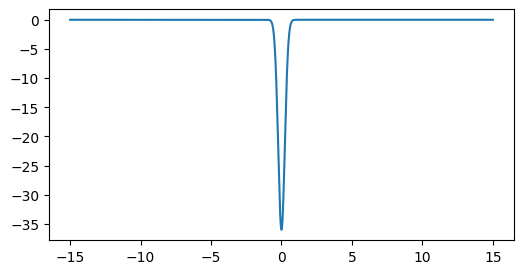

In [31]:
plt.figure(figsize=(6,3))
plt.plot(x, V(x,V0))
plt.show()

In [32]:
Es, psis = solve_single_well(x, V, V0)

Look at the energies

In [33]:
f*Es

array([-21.37895221,  -1.35778458])

Plot all the wavefunctions

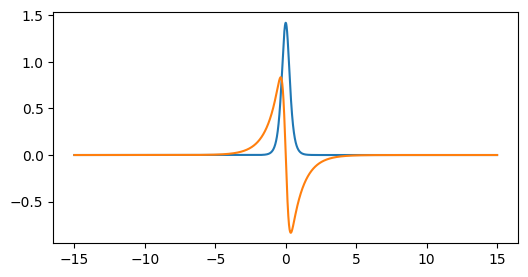

In [34]:
plt.figure(figsize=(6,3))
[plt.plot(x, psi) for psi in psis]
plt.show()

In order to solve our integral, lets create a function that can compute the wavefunctions at any point $x$

In [35]:
psis_f = [interp1d(x, psi, bounds_error=False, fill_value=(0,0)) for psi in psis]

Define $\hat{V}(x)$: the potential from all the wells, **except** the one centered at $x=0$.

In [36]:
def Vp_f(x, b, V0):
    return V((x+b/2)%b-b/2,V0) - V(x,V0)

Plot the ground state wavefunctions from consecutive wells, along with $\hat{V}(x)$

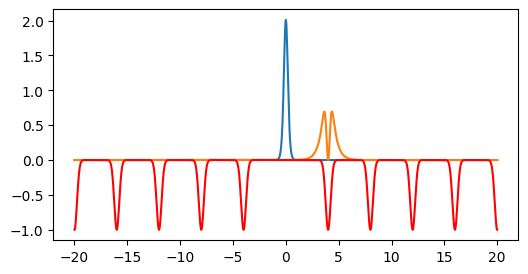

In [37]:
x_large = np.linspace(-20,20,10000)
plt.figure(figsize=(6,3))
plt.plot(x_large, psis_f[0](x_large)**2)
plt.plot(x_large, psis_f[1](x_large - b)**2)
plt.plot(x_large, Vp_f(x_large,b,V0)/V0, color='red')
plt.show()

Function that computes $\int_{-\infty}^{\infty} \phi_i^{*}(x) \left[E_i+\hat{V}(x)\right]\phi_{i'}(x \pm nb) dx$

In [38]:
def compute_integral(psis_f, Es, i1, i2, b, V0, n):
    return quad(lambda x: psis_f[i1](x)*psis_f[i2](x-n*b)*(Es[i1]+Vp_f(x, b, V0)),
                -20, 20, points=[n*b for n in range(-6,6)], limit=1000)[0]  

In [39]:
f*compute_integral(psis_f,Es,0,0, b=6, V0=V0, n=1)

-1.5380149840051426e-09

## Fill the Hamiltonian matrix $H$

**Part 1**: Create Matrix

In [40]:
N_wells = 20
N_states = len(Es)
H = np.zeros((N_wells*N_states,N_wells*N_states))

**Part 2**: Fill Off diagonals

In [41]:
psis_tot = N_wells*psis_f
Es_tot = N_wells*list(Es)
for i1 in range(H.shape[0]):
    for i2 in range(i1, H.shape[0]):
        well1_idx = i1//N_states
        well2_idx = i2//N_states
        H[i1,i2] = compute_integral(psis_tot,Es_tot,i1,i2,b=b,V0=V0,n=well2_idx-well1_idx)
H += H.T

**Part 3**: Fill Main diagonal

In [42]:
main_diag = np.array(list(Es)*N_wells)
H[np.diag_indices(H.shape[0])] = main_diag

Show a visual representation of the Hamiltonian

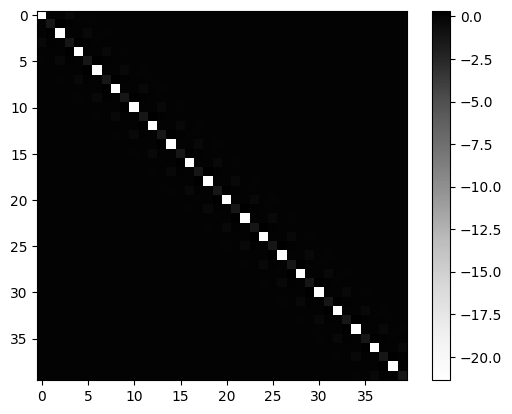

In [43]:
plt.imshow(H, cmap='Greys')
plt.colorbar()
plt.show()

Solve for the allowed energies and states of an electron in this system:

In [44]:
eigenenergies, eigenvectors = np.linalg.eigh(H)

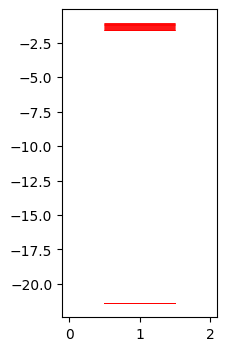

In [45]:
plt.figure(figsize=(2,4))
plt.eventplot(f*eigenenergies, orientation='vertical', colors='r', linewidths=0.5)
plt.show()

In [46]:
eigenenergies

array([-21.40124597, -21.40124536, -21.39977253, -21.39977022,
       -21.39746258, -21.39745779, -21.39452121, -21.39451363,
       -21.39120959, -21.39119943, -21.38782184, -21.38780979,
       -21.38465895, -21.38464591, -21.38200216, -21.38198881,
       -21.38008837, -21.38007387, -21.37909388, -21.37906423,
        -1.59169285,  -1.58355975,  -1.57019826,  -1.55189484,
        -1.52904249,  -1.50213293,  -1.47174689,  -1.43854263,
        -1.40324295,  -1.36662076,  -1.32948347,  -1.2926563 ,
        -1.25696471,  -1.22321615,  -1.19218148,  -1.16457641,
        -1.1410434 ,  -1.12213481,  -1.10829764,  -1.09986093])

**For example 1**: Theoretically, the allowed energies are 

In [47]:
idx = eigenenergies>-1

## COMPUTATION USING HARDTREE FOCK

In [50]:
BASIS_SIZE = 2  # Two 1s orbitals
MAX_ITER = 50   # Maximum SCF iterations
CONV_CRIT = 1e-7 # Convergence threshold

In [ ]:
# Make Matrix
S = np.array([[1.0, 0.6593], 
              [0.6593, 1.0]])

H_core = np.array([[-1.1204, -0.9584], 
                   [-0.9584, -1.1204]])

g = np.zeros((2, 2, 2, 2))
g[0,0,0,0] = 0.7746; g[1,1,1,1] = 0.7746
g[0,0,1,1] = 0.5697; g[1,1,0,0] = 0.5697
g[0,1,0,1] = 0.2227; g[1,0,1,0] = 0.2227
g[0,1,1,1] = 0.4446; g[1,1,0,1] = 0.4446 

In [52]:
evals, evecs = np.linalg.eigh(S)
X = evecs @ np.diag(evals**-0.5) @ evecs.T

print("Orthogonalization matrix X created successfully.")

Orthogonalization matrix X created successfully.


In [53]:
P = np.zeros((BASIS_SIZE, BASIS_SIZE))
E_old = 0.0

print(f"{'Iteration':<12} | {'Electronic Energy (Ha)':<22} | {'Delta E':<15}")
print("-" * 55)

for i in range(MAX_ITER):
    # Build the Fock Matrix (F = H + G)
    G = np.zeros((BASIS_SIZE, BASIS_SIZE))
    for mu in range(BASIS_SIZE):
        for nu in range(BASIS_SIZE):
            for la in range(BASIS_SIZE):
                for si in range(BASIS_SIZE):
                    # Coulomb and Exchange interactions
                    G[mu, nu] += P[la, si] * (g[mu, nu, la, si] - 0.5 * g[mu, la, nu, si])
    
    F = H_core + G
    
    # Transform Fock to orthogonal basis: F' = X.T @ F @ X
    F_prime = X.T @ F @ X
    
    # Diagonalize F' to get energies and coefficients
    epsilon, C_prime = np.linalg.eigh(F_prime)
    
    # Transform coefficients back to original basis: C = X @ C'
    C = X @ C_prime
    
    # Update Density Matrix P (for 2 electrons in the lowest orbital)
    P_new = np.zeros((BASIS_SIZE, BASIS_SIZE))
    for mu in range(BASIS_SIZE):
        for nu in range(BASIS_SIZE):
            P_new[mu, nu] = 2 * C[mu, 0] * C[nu, 0]
    
    # Calculate Total Electronic Energy
    E_elec = 0.5 * np.sum(P_new * (H_core + F))
    delta_e = np.abs(E_elec - E_old)
    
    print(f"{i:<12} | {E_elec:<22.8f} | {delta_e:<15.2e}")
    
    if delta_e < CONV_CRIT:
        print("\nConvergence achieved.")
        break
        
    P = P_new
    E_old = E_elec

Iteration    | Electronic Energy (Ha) | Delta E        
-------------------------------------------------------
0            | -2.50563491            | 2.51e+00       
1            | -2.15002632            | 3.56e-01       
2            | -2.14769680            | 2.33e-03       
3            | -2.14703223            | 6.65e-04       
4            | -2.14698371            | 4.85e-05       
5            | -2.14698051            | 3.20e-06       
6            | -2.14698030            | 2.09e-07       
7            | -2.14698029            | 1.37e-08       

Convergence achieved.


Total Molecular Energy: -1.43328 Hartree

Molecular Orbital Coefficients (Columns are MOs):
[[-0.6333248  -1.16952912]
 [-0.46179449  1.24725479]]


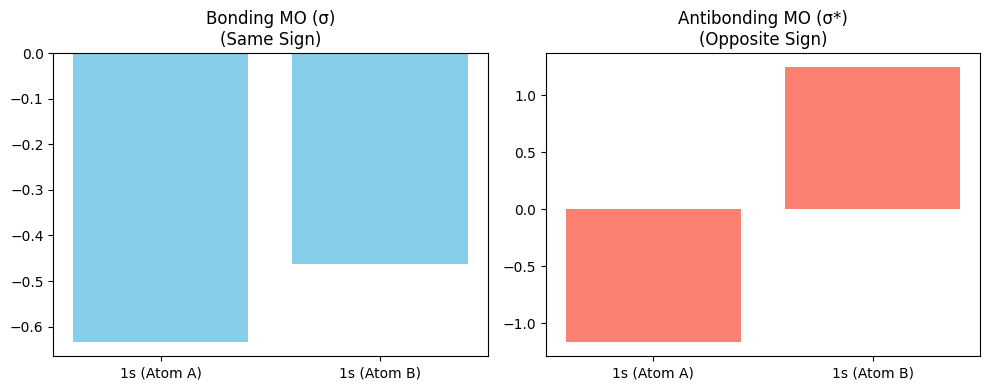

In [54]:
E_total = E_elec + 0.7137

print(f"Total Molecular Energy: {E_total:.5f} Hartree")
print("\nMolecular Orbital Coefficients (Columns are MOs):")
print(C)

# Simple visual representation of the MOs
labels = ['1s (Atom A)', '1s (Atom B)']
x = np.arange(len(labels))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(x, C[:, 0], color='skyblue')
ax[0].set_title("Bonding MO (σ)\n(Same Sign)")
ax[0].set_xticks(x, labels)

ax[1].bar(x, C[:, 1], color='salmon')
ax[1].set_title("Antibonding MO (σ*)\n(Opposite Sign)")
ax[1].set_xticks(x, labels)

plt.tight_layout()
plt.show()